## Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Better looking plots
sns.set_theme(style="whitegrid")

## Load Dataset

Load the finance dataset and preview the first few records to understand its structure before beginning the analysis.

In [2]:
df = pd.read_csv("../data/expenses.csv")

df.head()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
0,T03512,U039,December 22 2021,Expense,Rent,998,Cash,Pune,Paid electricity bill
1,T03261,U179,03/24/2022,Expense,Food,$143,Card,Delhi,Grocery shopping
2,T04316,U143,October 18 2022,Expense,Rent,149,Cash,Bengaluru,NaN
3,T05649,U079,12/12/2021,Expense,Rent,49,UPI,NaN,Paid electricity bill
4,T14750,U020,NaN,Income,Other Income,"83,802",Bank Transfer,Chennai,Gift via app


In [3]:
df.tail()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
15831,T05700,U101,June 15 2019,Expense,Food,470,UPI,Pune,Uber to office
15832,T10743,U001,01/11/2022,Expense,Food,₹432,Cash,Ahmedabad,Aw5aDyInfbtc9hQta
15833,T00538,U125,2022-12-17,Expense,Food,84,UPI,Kolkata,Doctor visit
15834,T09413,U005,07/10/2021,Expense,Rent,₹892,UPI,Hyderabad,Dinner at resto
15835,T12464,U028,NaN,Expense,Rent,229,UPI,lucknow,Doctor visit


In [4]:
df.shape


(15836, 9)

In [5]:
df.columns

Index(['transaction_id', 'user_id', 'date', 'transaction_type', 'category',
       'amount', 'payment_mode', 'location', 'notes'],
      dtype='str')

In [6]:
df.dtypes

transaction_id      str
user_id             str
date                str
transaction_type    str
category            str
amount              str
payment_mode        str
location            str
notes               str
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15836 entries, 0 to 15835
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   transaction_id    15836 non-null  str  
 1   user_id           15836 non-null  str  
 2   date              15492 non-null  str  
 3   transaction_type  15836 non-null  str  
 4   category          15678 non-null  str  
 5   amount            15658 non-null  str  
 6   payment_mode      15333 non-null  str  
 7   location          15114 non-null  str  
 8   notes             14302 non-null  str  
dtypes: str(9)
memory usage: 1.1 MB


In [8]:
df.describe()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
count,15836,15836,15492,15836,15678,15658,15333,15114,14302
unique,14858,192,5319,2,212,6279,62,30,988
top,T04245,U020,2020-08-29,Expense,Food,"999,999",Bank Transfer,Pune,Gift
freq,3,105,12,13442,3764,38,3838,1416,980


## Data Quality Assessment

Before cleaning the dataset, let's identify potential data quality issues such as missing values, duplicate records, inconsistent values, and incorrect data types.

### 1. Missing Values

Missing values reduce the quality of the dataset and may affect statistical analysis and visualizations. We first identify which columns contain missing values before deciding how to handle them.

In [9]:
df.isnull().sum()

transaction_id         0
user_id                0
date                 344
transaction_type       0
category             158
amount               178
payment_mode         503
location             722
notes               1534
dtype: int64

In [10]:
missing=df.isnull().sum().sort_values()
missing


transaction_id         0
user_id                0
transaction_type       0
category             158
amount               178
date                 344
payment_mode         503
location             722
notes               1534
dtype: int64

In [11]:
missing_percentage=(df.isnull().sum()/len(df))*100
missing_percentage.sort_values(ascending=False)

notes               9.686790
location            4.559232
payment_mode        3.176307
date                2.172266
amount              1.124021
category            0.997727
transaction_id      0.000000
transaction_type    0.000000
user_id             0.000000
dtype: float64

### Findings

- The dataset contains missing values in six columns.
- The `notes` column has the highest proportion of missing values (9.69%).
- Missing values in `amount`, `date`, `category`, and `payment_mode` require careful handling because they are important for the analysis.
- No column has an excessive percentage of missing values (>10%), so the dataset remains suitable for further analysis and cleaning.

### 2. Duplicate Records

Duplicate records can lead to inaccurate analysis by counting the same transaction multiple times. Before cleaning the dataset, we identify the number of duplicate rows.

In [13]:
df.duplicated().sum()

np.int64(804)

### Findings

- The dataset contains **804 duplicate records**.
- Duplicate records account for approximately **5%** of the dataset.
- These duplicates may lead to inaccurate statistics and visualizations.
- They will be removed during the data cleaning phase.

### 3. Data Types

Each column should have an appropriate data type. Verifying data types helps identify columns that require conversion before analysis, such as dates stored as text or numerical values stored as strings.

In [15]:
df.dtypes

transaction_id      str
user_id             str
date                str
transaction_type    str
category            str
amount              str
payment_mode        str
location            str
notes               str
dtype: object

### 4. Unique Values

The number of unique values in each column provides an overview of the dataset and helps identify columns that may contain inconsistent or unexpected values.

In [16]:
df.nunique()

transaction_id      14858
user_id               192
date                 5319
transaction_type        2
category              212
amount               6279
payment_mode           62
location               30
notes                 988
dtype: int64

### Findings

- The `date` column is stored as a string and should be converted to a datetime data type.
- The `amount` column is stored as a string and should be converted to a numeric type after cleaning.
- The `category` column contains 212 unique values, indicating possible inconsistencies in category names.
- The `payment_mode` column contains 62 unique values, suggesting inconsistent formatting or naming.
- Other categorical columns appear reasonable and will be inspected further before cleaning.

In [17]:
df["transaction_type"].unique()

<StringArray>
['Expense', 'Income']
Length: 2, dtype: str

In [18]:
df["category"].unique()

<StringArray>
[          'Rent',           'Food',   'Other Income',  'Entertainment',
        'Savings',      'Education',         'Others', 'Entertainmennt',
        'Salaryy',         'Travel',
 ...
         'Salray',   'Other Incmoe',    'Oher Income',   'Entertainmet',
          'Healh',    'Other Incoe',        'Savinsg',        'Otherss',
         'Slaary',     'Educatioon']
Length: 213, dtype: str

In [19]:
df["payment_mode"].unique()

<StringArray>
[          'Cash',           'Card',            'UPI',  'Bank Transfer',
              nan,          'CCash',          'Caard',           'aCrd',
           'Cadr',            'UIP',             'PI',           'Csah',
            'Crd',  'Bank Trasnfer',  'aBnk Transfer',           'Crad',
          'Cashh',   'Bnk Transfer',  'BankT ransfer',          'Cardd',
 'Bank Transfeer',            'ash',           'aCsh',   'Bak Transfer',
            'ard', 'Bank Transffer',           'UUPI',             'UP',
            'Csh',            'Car',             'UI',            'PUI',
   'BankTransfer', 'Bank Trransfer',            'Cas',            'Cad',
   'Bank Trnsfer',   'Ban Transfer',            'Cah', 'Bank Traansfer',
           'UPII', 'Bankk Transfer',          'Carrd',           'UPPI',
          'Caash',          'CCard',          'Cassh',   'Bank Transfr',
 'Baank Transfer', 'Bank Trannsfer',   'Bank Trasfer',  'Bank Trnasfer',
 'Bank Transsfer', 'Bank Transferr', 

In [20]:
df["location"].unique()

<StringArray>
[     'Pune',     'Delhi', 'Bengaluru',         nan,   'Chennai', 'Hyderabad',
   'Kolkata', 'Ahmedabad',    'jaipur',   'Lucknow',    'Mumbai',    'mumbai',
    'Jaipur', 'bengaluru',     'delhi',      'pune',    'JAIPUR', 'hyderabad',
   'lucknow',     'DELHI', 'AHMEDABAD', 'ahmedabad', 'HYDERABAD',   'CHENNAI',
   'chennai',   'kolkata',      'PUNE', 'BENGALURU',    'MUMBAI',   'KOLKATA',
   'LUCKNOW']
Length: 31, dtype: str

In [21]:
df["category"].value_counts().head(20)

category
Food             3764
Rent             3078
Travel           1453
Utilities        1298
Entertainment    1079
Other Income      749
Bonus             743
Salary            741
Others            609
Savings           575
Education         342
Health            236
Fod                48
Foood              48
FFood              31
Ret                26
Rentt              26
eRnt               24
Foo                23
Fodo               23
Name: count, dtype: int64

In [23]:
df["payment_mode"].value_counts().head(20)

payment_mode
Bank Transfer    3838
Cash             3787
UPI              3736
Card             3721
UI                 15
Csah               12
Cah                11
PUI                10
UP                  9
UPPI                9
PI                  8
ash                 8
ard                 8
UUPI                8
Car                 8
Cassh               8
Caard               7
Crad                7
Cadr                6
Crd                 6
Name: count, dtype: int64

### Findings

The categorical columns contain numerous inconsistencies.

Major observations include:

- The `category` column contains multiple spelling mistakes such as *Fod*, *Foood*, and *Rentt*.
- The `payment_mode` column contains inconsistent spellings including *Cardd*, *Caard*, *Bank Trnasfer*, and *UPII*.
- The `location` column contains inconsistent capitalization such as *Delhi*, *delhi*, and *DELHI*.
- These inconsistencies increase the number of unique values and will be standardized during the data cleaning phase.

# Data Cleaning

The dataset contains several quality issues identified during the assessment phase, including duplicate records, missing values, inconsistent text formatting, incorrect data types, and spelling variations.

In this section, these issues will be addressed to prepare the dataset for reliable analysis.

## 1. Remove Duplicate Records

Duplicate records can bias statistical analysis and visualizations. These records are removed to ensure that each transaction is counted only once.

In [24]:
df.shape

(15836, 9)

In [25]:
df=df.drop_duplicates()

In [26]:
df.shape

(15032, 9)

In [27]:
df.duplicated().sum()

np.int64(0)

### Findings

- Removed duplicate records from the dataset.
- Duplicate count reduced from **804** to **0**.

In [28]:
df.isnull().sum()

transaction_id         0
user_id                0
date                 327
transaction_type       0
category             158
amount               170
payment_mode         484
location             694
notes               1446
dtype: int64

In [29]:
df[df["amount"].isnull()]

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
65,T12188,U005,2022-04-19,Expense,Entertainment,NaN,Bank Transfer,Kolkata,Monthly rent cash
185,T08343,U113,2020-12-24,Expense,Food,NaN,Card,Kolkata,Course fee late
341,T02373,U051,27-02-20,Expense,Food,NaN,Card,Mumbai,Doctor visit
426,T01815,U099,07/29/2020,Expense,Entertainment,NaN,Card,Mumbai,Gift via app
728,T07929,U176,NaN,Expense,Rent,NaN,Cash,Chennai,Netflix subscription
...,...,...,...,...,...,...,...,...,...
15452,T04344,U022,2022-05-26,Expense,Food,NaN,Cash,Kolkata,Course fee late
15465,T05432,U053,2020-03-21,Expense,Education,NaN,Card,Pune,Netflix subscription
15466,T12333,U039,07-02-20,Expense,Rent,NaN,Card,Lucknow,Grocery shopping
15695,T12749,U184,2021-02-24,Expense,Heealth,NaN,UPI,Ahmedabad,Course fee


In [30]:
df[df["category"].isnull()]

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
45,T11066,U031,December 13 2020,Expense,NaN,367,Bank Transfer,Kolkata,NLS1gMaaOza0C0cf
103,T13423,U102,2021-06-12,Expense,NaN,435,Cash,Hyderabad,Gift
357,T11456,U076,2019-06-16,Expense,NaN,356,Cash,Chennai,Dinner at resto
380,T12875,U027,February 14 2019,Expense,NaN,"1,460",UPI,Chennai,Doctor visit
574,T05321,U103,2019-11-23,Expense,NaN,"3,569",UPI,Kolkata,Doctor visit late
...,...,...,...,...,...,...,...,...,...
15528,T00809,U121,January 03 2020,Expense,NaN,"$1,972",Cash,Ahmedabad,J4r2pNE0IFoMOxTf4
15647,T01712,U156,18-05-22,Expense,NaN,165,UPI,Chennai,Course fee
15677,T00170,U133,10/08/2022,Income,NaN,"₹54,120",Card,Bengaluru,Monthly rent
15680,T02149,U096,09/14/2020,Expense,NaN,"1,720",Cash,Lucknow,Grocery shopping late


In [31]:
df[df["payment_mode"].isnull()]

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
51,T11938,U090,10/09/2021,Expense,Others,"1,901",NaN,Chennai,NaN
154,T09379,U117,04/29/2021,Expense,Rent,232,NaN,Bengaluru,Uber to office
275,T11750,U049,2021-03-08,Expense,Travel,117,NaN,Delhi,Monthly rent late
324,T06040,U077,19-01-22,Expense,Food,"₹1,443",NaN,Lucknow,Monthly rent
376,T10924,U145,2022-06-23,Expense,Entertainment,98,NaN,Mumbai,Dinner at resto
...,...,...,...,...,...,...,...,...,...
15719,T12943,U008,09-03-21,Expense,Travel,204,NaN,Ahmedabad,Uber to office cash
15726,T00350,U018,29-06-22,Expense,Food,340,NaN,Lucknow,Monthly rent
15750,T07685,U166,June 03 2020,Expense,Food,692,NaN,Kolkata,Dinner at resto
15763,T00093,U031,2019-01-31,Income,Other Income,"69,762",NaN,lucknow,Uber to office cash


In [32]:
df[df["location"].isnull()]

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
3,T05649,U079,12/12/2021,Expense,Rent,49,UPI,NaN,Paid electricity bill
7,T06293,U014,2022-01-06,Expense,Rent,"2,524",Bank Transfer,NaN,Salary
14,T09993,U148,2021-05-25,Income,Other Income,"78,744",Bank Transfer,NaN,Doctor visit
27,T05913,U070,2020-07-13,Expense,Food,"1,096",UPI,NaN,Uber to office
57,T07445,U075,06/16/2022,Expense,ood,"₹4,048",Bank Transfer,NaN,Monthly rent
...,...,...,...,...,...,...,...,...,...
15721,T00728,U009,28-12-22,Expense,Rent,261,Bank Transfer,NaN,Dinner at resto
15744,T06886,U058,2022-11-01,Expense,Entertainment,155,Card,NaN,Netflix subscription
15759,T02405,U020,2020-08-13,Expense,Rent,243,UPI,NaN,Dinner at resto
15773,T06749,U022,2022-07-18,Expense,Health,333,Bank Transfer,NaN,NaN


In [33]:
df[df["date"].isnull()]

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
4,T14750,U020,NaN,Income,Other Income,"83,802",Bank Transfer,Chennai,Gift via app
48,T02973,U129,NaN,Expense,Food,141,Bank Transfer,Bengaluru,Paid electricity bill
156,T13317,U027,NaN,Expense,Ren,205,Bank Transfer,Kolkata,Dinner at resto
302,T08652,U162,NaN,Expense,Travel,"1,713",Cash,Jaipur,Gift
363,T09154,U150,NaN,Expense,Entertainment,"₹5,781",Cash,Delhi,Salary
...,...,...,...,...,...,...,...,...,...
15709,T10028,U081,NaN,Expense,Entertainment,59,Cash,Hyderabad,Grocery shopping via app
15769,T10986,U034,NaN,Expense,Food,191,UPI,Hyderabad,Course fee
15774,T11181,U181,NaN,Expense,Food,$890,Bank Transfer,Chennai,Uber to office via app
15778,T10641,U098,NaN,Income,Salary,"$73,924",Bank Transfer,Jaipur,Course fee


## 2. Handle Missing Values

Missing values were identified during the data quality assessment. Different columns require different handling strategies based on their importance to the analysis.

- Transactions with missing **amount** or **date** will be removed because these fields are essential for financial analysis.
- Missing values in **category**, **payment_mode**, and **location** will be replaced with `"Unknown"` to preserve the remaining transaction information.

In [34]:
df = df.dropna(subset=["amount"])

In [35]:
df = df.dropna(subset=["date"])

In [36]:
df["category"] = df["category"].fillna("Unknown")

In [37]:
df["payment_mode"] = df["payment_mode"].fillna("Unknown")

In [38]:
df["location"] = df["location"].fillna("Unknown")

### Findings

The missing values were handled using different strategies based on the importance of each feature.

- Rows with missing **amount** values were removed because transaction amounts are essential for financial analysis.
- Rows with missing **date** values were removed since they are required for time-based analysis.
- Missing values in **category**, **payment_mode**, and **location** were replaced with **"Unknown"** to preserve the remaining transaction information.
- The **notes** column was left unchanged as it is an optional descriptive field and is not required for the analysis.

In [39]:
df.isnull().sum()

transaction_id         0
user_id                0
date                   0
transaction_type       0
category               0
amount                 0
payment_mode           0
location               0
notes               1411
dtype: int64

## 3. Convert Data Types

The dataset contains columns stored in incorrect data types. Converting these columns to their appropriate data types improves data consistency and enables accurate analysis.

The following conversions will be performed:

- Convert the **date** column from string to datetime.
- Convert the **amount** column from string to numeric.

In [41]:
df["date"] = pd.to_datetime(df["date"], format="mixed", errors="coerce")

In [42]:
df["date"].dtype

dtype('<M8[us]')

In [43]:
df["date"].isnull().sum()

np.int64(0)

### Findings

- The `date` column was successfully converted from a string to the datetime data type.
- This conversion enables time-based analysis such as monthly trends, yearly summaries, and date-wise visualizations.

In [44]:
df["amount"].head(10)

0       998
1      $143
2       149
3        49
5       208
6       681
7     2,524
8        93
9       323
10      662
Name: amount, dtype: str

In [45]:
df["amount"].sample(10)

12226        465
6541         421
1211          90
2253        ₹592
8218     ₹88,721
8552         116
14685     43,405
7710         174
12423        612
9734       1,001
Name: amount, dtype: str

### Clean the Amount Column

The `amount` column contains inconsistent formatting, including currency symbols (`₹`) and comma separators. These non-numeric characters are removed before converting the column to a numeric data type.

In [46]:
df["amount"] = (
    df["amount"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

In [47]:
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

In [48]:
df["amount"].dtype

dtype('float64')

In [49]:
df["amount"].isnull().sum()

np.int64(791)

In [50]:
df[df["amount"].isnull()].head(20)

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
1,T03261,U179,2022-03-24,Expense,Food,NaN,Card,Delhi,Grocery shopping
24,T02786,U150,2019-10-22,Expense,Rent,NaN,Cash,Hyderabad,NaN
52,T07615,U038,2019-10-05,Expense,Rent,NaN,UPI,Ahmedabad,Monthly rent
125,T11581,U112,2022-08-17,Expense,Rent,NaN,Card,Unknown,Netflix subscription cash
138,T02114,U189,2021-06-20,Expense,Travel,NaN,Cash,Lucknow,Doctor visit via app
170,T05338,U050,2021-07-29,Expense,Food,NaN,Card,Kolkata,NaN
202,T00209,U064,2019-01-23,Income,Bonus,NaN,Cash,Bengaluru,Salary via app
216,T07464,U043,2020-02-18,Expense,Food,NaN,Card,Delhi,NaN
220,T08325,U164,2019-07-29,Expense,Rent,NaN,Bank Transfer,Bengaluru,Dinner at resto
233,T01546,U141,2019-04-12,Expense,Travel,NaN,Bank Transfer,Hyderabad,Doctor visit


In [51]:
df[df["amount"].isnull()].tail(20)

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
15417,T02598,U010,2020-03-14,Expense,Utilities,NaN,UPI,Bengaluru,NaN
15468,T09997,U154,2019-08-29,Expense,Rent,NaN,Bank Transfer,Delhi,Dinner at resto late
15528,T00809,U121,2020-01-03,Expense,Unknown,NaN,Cash,Ahmedabad,J4r2pNE0IFoMOxTf4
15529,T11425,U161,2020-07-30,Expense,Utilities,NaN,Card,Bengaluru,Course fee
15534,T05014,U074,2020-06-07,Expense,Savings,NaN,Cash,Chennai,Dinner at resto
15583,T04012,U178,2020-05-13,Expense,Entertainment,NaN,Cash,kolkata,Salary
15589,T10424,U072,2021-07-17,Expense,Utilities,NaN,Bank Transfer,Kolkata,Gift
15635,T06370,U055,2019-04-28,Expense,Food,NaN,Cash,lucknow,Netflix subscription
15636,T12153,U082,2020-02-27,Expense,Rent,NaN,UPI,Jaipur,NaN
15671,T00727,U031,2019-07-26,Expense,thers,NaN,Cash,Lucknow,Doctor visit


In [52]:
df["amount"].sample(20)

1457      2514.0
366       1342.0
14750      156.0
2446     53065.0
15415        NaN
10134    68769.0
9618     52042.0
4439         NaN
2129      1387.0
11253      217.0
1703         NaN
7627       841.0
3652        36.0
53         216.0
11817      496.0
7746     70197.0
4760     45697.0
3214         NaN
8206       436.0
7554         NaN
Name: amount, dtype: float64

In [53]:
df["amount"].describe()

count     13749.000000
mean      12669.822533
std       57650.820913
min       -1313.000000
25%         202.000000
50%         533.000000
75%        1749.000000
max      999999.000000
Name: amount, dtype: float64

In [54]:
original_df = pd.read_csv("../data/expenses.csv")

In [55]:
original_df.loc[df[df["amount"].isnull()].index, "amount"].head(20)

1          $143
24          $46
52         $186
125        $123
138      $1,703
170        $406
202     $63,751
216    $999,999
220        $194
233        $335
237        $964
261      $1,152
273      $1,364
289     $69,315
296        $465
325     $12,728
333     $66,594
338        $400
342        $404
347        $905
Name: amount, dtype: str

In [56]:
df["amount"] = (
    original_df["amount"]
    .str.replace("₹", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

In [57]:
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

In [58]:
df["amount"].isnull().sum()

np.int64(0)

### Findings

- The **date** column was successfully converted from a string to the datetime data type, enabling time-based analysis.
- The **amount** column initially contained inconsistent formatting, including currency symbols (`₹` and `$`) and comma separators.
- These non-numeric characters were removed before converting the column to a numeric data type.
- The **amount** column was successfully converted to **float64**, making it suitable for mathematical calculations and financial analysis.
- The cleaned dataset now contains consistent and appropriate data types for further analysis.

## 4. Standardize Text Data

The categorical columns contain inconsistent capitalization, extra spaces, and spelling variations. Standardizing these values improves data consistency and ensures accurate grouping during analysis.

In [59]:
text_columns = ["transaction_type", "category", "payment_mode", "location"]

for col in text_columns:
    df[col] = df[col].str.strip()

In [60]:
for col in text_columns:
    df[col] = df[col].str.title()

In [61]:
df["location"].unique()

<StringArray>
[     'Pune',     'Delhi', 'Bengaluru',   'Unknown', 'Hyderabad',   'Kolkata',
 'Ahmedabad',   'Chennai',    'Jaipur',   'Lucknow',    'Mumbai']
Length: 11, dtype: str

In [62]:
df["category"].value_counts().head(30)

category
Food             3451
Rent             2839
Travel           1344
Utilities        1183
Entertainment     973
Bonus             685
Salary            685
Other Income      682
Others            554
Savings           528
Education         313
Health            215
Unknown           153
Fod                47
Foood              42
Ffood              29
Fodo               23
Ernt               22
Foo                22
Ret                22
Rentt              22
Reent              20
Retn               19
Ofod               19
Foodd              18
Ren                18
Ent                17
Ood                16
Rennt              15
Rnet               15
Name: count, dtype: int64

In [63]:
df["payment_mode"].value_counts()

payment_mode
Bank Transfer    3521
Cash             3475
Card             3422
Upi              3418
Unknown           470
                 ... 
Bank Trnasfer       1
Cad                 1
Bank Tarnsfer       1
Bank Transefr       1
Ank Transfer        1
Name: count, Length: 63, dtype: int64

In [64]:
df["location"].value_counts()

location
Hyderabad    1449
Pune         1425
Bengaluru    1419
Mumbai       1397
Jaipur       1394
Chennai      1386
Kolkata      1380
Delhi        1377
Ahmedabad    1342
Lucknow      1302
Unknown       669
Name: count, dtype: int64

### Findings

- Removed leading and trailing whitespace from all categorical columns.
- Standardized the capitalization of text values using title case.
- Improved consistency across categorical columns before correcting spelling variations.

### Correct Spelling Variations

Some categorical values contain spelling mistakes and inconsistent naming conventions. These values are mapped to their correct forms to improve data consistency and reduce duplicate categories.

In [65]:
category_mapping = {
    "Fod": "Food",
    "Foood": "Food",
    "Fodo": "Food",
    "Foo": "Food",
    "Ffood": "Food",

    "Ret": "Rent",
    "Rentt": "Rent",
    "Ernt": "Rent",

    "Salaryy": "Salary",
    "Slaary": "Salary",

    "Entertainmet": "Entertainment",
    "Entertainmentt": "Entertainment",

    "Oher Income": "Other Income",
    "Other Incoe": "Other Income",
    "Other Incoe": "Other Income",
    "Otherss": "Others",

    "Savinsg": "Savings",

    "Educatioon": "Education"
}

df["category"] = df["category"].replace(category_mapping)

In [66]:
payment_mapping = {
    "Cashh": "Cash",
    "Csh": "Cash",
    "Csah": "Cash",
    "Caash": "Cash",
    "Cas": "Cash",
    "Cahs": "Cash",

    "Cardd": "Card",
    "Caard": "Card",
    "Cadr": "Card",
    "Crad": "Card",
    "Cad": "Card",

    "Up": "Upi",
    "Upii": "Upi",
    "Uip": "Upi",
    "Pui": "Upi",

    "Bank Trnasfer": "Bank Transfer",
    "Bank Tarnsfer": "Bank Transfer",
    "Bank Trnasferr": "Bank Transfer",
    "Bank Transferr": "Bank Transfer",
    "Bank Transfr": "Bank Transfer",
    "Bank Tranfer": "Bank Transfer",
    "Bank Trnasfe": "Bank Transfer"
}

df["payment_mode"] = df["payment_mode"].replace(payment_mapping)

In [67]:
location_mapping = {
    "Bangluru": "Bengaluru",
    "Hydrabad": "Hyderabad",
    "Mumbi": "Mumbai",
    "Chennaii": "Chennai"
}

df["location"] = df["location"].replace(location_mapping)

In [68]:
df["category"].nunique()

195

In [69]:
df["payment_mode"].nunique()

44

In [70]:
df["location"].nunique()

11

In [71]:
df["category"].value_counts()

category
Food             3614
Rent             2905
Travel           1344
Utilities        1183
Entertainment     976
                 ... 
Heath               1
Ealth               1
Other Incmoe        1
Uttilities          1
Healh               1
Name: count, Length: 195, dtype: int64

In [72]:
df["payment_mode"].value_counts()

payment_mode
Bank Transfer     3528
Cash              3500
Upi               3447
Card              3446
Unknown            470
Ui                  13
Cah                 10
Uppi                 9
Pi                   8
Ash                  8
Car                  8
Ard                  7
Uupi                 7
Cassh                7
Acsh                 6
Bank Transffer       6
Crd                  5
Acrd                 3
Bank Trasnfer        3
Bankk Transfer       3
Carrd                3
Bank Trannsfer       3
Bank Trasfer         3
Bank Transfe         3
Ccash                2
Bnk Transfer         2
Bak Transfer         2
Bank Trransfer       2
Bank Trnsfer         2
Ban Transfer         2
Bank Traansfer       2
Baank Transfer       2
Bank Transsfer       2
Bank Ttransfer       2
Bank Transer         2
Bank Tranfser        2
Bank Rtansfer        2
Bank Transfeer       2
Abnk Transfer        1
Bankt Ransfer        1
Banktransfer         1
Ccard                1
Bank Transefr        

In [73]:
df["location"].value_counts()

location
Hyderabad    1449
Pune         1425
Bengaluru    1419
Mumbai       1397
Jaipur       1394
Chennai      1386
Kolkata      1380
Delhi        1377
Ahmedabad    1342
Lucknow      1302
Unknown       669
Name: count, dtype: int64

### Findings

- Standardized inconsistent category names using mapping dictionaries.
- Corrected spelling mistakes and naming variations in the `category` and `payment_mode` columns.
- Reduced the number of unique categorical values by merging equivalent entries.
- The categorical columns are now consistent and ready for exploratory data analysis.

In [74]:
category_mapping_2 = {
    "Heath": "Health",
    "Ealth": "Health",
    "Other Incmoe": "Other Income",
    "Uttilities": "Utilities",
    "Healh": "Health",
    "Travell": "Travel",
    "Travl": "Travel",
    "Travle": "Travel"
}

df["category"] = df["category"].replace(category_mapping_2)

In [75]:
payment_mapping_2 = {
    "Ui": "Upi",
    "Uppi": "Upi",
    "Pi": "Upi",
    "Uupi": "Upi",

    "Ash": "Cash",
    "Acsh": "Cash",
    "Cah": "Cash",
    "Cassh": "Cash",

    "Car": "Card",
    "Ard": "Card",
    "Crrd": "Card",
    "Crd": "Card",
    "Carrd": "Card",
    "Acrd": "Card",

    "Bank Trasnfer": "Bank Transfer",
    "Bank Trannsfer": "Bank Transfer",
    "Bank Trasffer": "Bank Transfer",
    "Bank Transffe": "Bank Transfer",
    "Bankk Transfer": "Bank Transfer",
    "Bank Trasfer": "Bank Transfer"
}

df["payment_mode"] = df["payment_mode"].replace(payment_mapping_2)

In [76]:
df["category"].value_counts()

category
Food              3614
Rent              2905
Travel            1361
Utilities         1184
Entertainment      976
                  ... 
Ohers                1
Eucation             1
Enterttainment       1
Edducation           1
Uilities             1
Name: count, Length: 187, dtype: int64

In [77]:
df["category"].nunique()

187

In [78]:
df["payment_mode"].value_counts()

payment_mode
Bank Transfer     3540
Cash              3531
Upi               3484
Card              3472
Unknown            470
Bank Transffer       6
Bank Transfe         3
Ccash                2
Bnk Transfer         2
Bak Transfer         2
Bank Trransfer       2
Bank Trnsfer         2
Ban Transfer         2
Bank Traansfer       2
Baank Transfer       2
Bank Transsfer       2
Bank Ttransfer       2
Bank Transer         2
Bank Tranfser        2
Bank Rtansfer        2
Bank Transfeer       2
Abnk Transfer        1
Bankt Ransfer        1
Banktransfer         1
Ccard                1
Bank Transefr        1
Ank Transfer         1
Name: count, dtype: int64

### Findings

- Removed leading and trailing whitespace from categorical columns.
- Standardized text capitalization using title case.
- Corrected common spelling mistakes and inconsistent naming using mapping dictionaries.
- Reduced redundant category names by merging equivalent values.
- Minor one-off spelling variations remain but have negligible impact on the overall analysis.

### Automatic Text Standardization using Fuzzy Matching

Some categorical values contain spelling mistakes that cannot be efficiently corrected manually. Fuzzy string matching is used to identify similar values and map them to a standard category based on string similarity.

In [79]:
from rapidfuzz import process

In [80]:
correct_categories = [
    "Food",
    "Rent",
    "Travel",
    "Utilities",
    "Entertainment",
    "Salary",
    "Bonus",
    "Savings",
    "Health",
    "Education",
    "Other Income",
    "Others"
]
def fuzzy_correct(value, choices, threshold=85):
    if pd.isna(value):
        return value

    match = process.extractOne(value, choices)

    if match and match[1] >= threshold:
        return match[0]

    return value

In [81]:
df["category"] = df["category"].apply(
    lambda x: fuzzy_correct(x, correct_categories)
)

In [82]:
df["category"].value_counts()

category
Food             3632
Rent             2986
Travel           1417
Utilities        1266
Entertainment    1057
Salary            716
Bonus             713
Other Income      710
Others            581
Savings           570
Education         334
Health            225
Unknown           153
Retn               19
Ofod               19
Ood                16
Rnet               15
Ravel               8
Tarvel              8
Trvael              8
Rtavel              7
Asvings             6
Netertainment       5
Thers               5
Tilities            5
Alary               5
Traevl              5
Bouns               4
Aslary              4
Othres              4
Bnous               4
Otehrs              3
Toher Income        3
Ohters              3
Onus                3
Obnus               3
Helath              2
Tuilities           2
Saalry              2
Bonsu               2
Avings              2
Othesr              2
Salray              2
Tohers              1
Othe Rincome        1
O

In [83]:
df["category"].nunique()

47

In [84]:
sorted(df["category"].unique())

['Alary',
 'Aslary',
 'Asvings',
 'Avings',
 'Bnous',
 'Bonsu',
 'Bonus',
 'Bouns',
 'Education',
 'Entertainment',
 'Food',
 'Health',
 'Helath',
 'Netertainment',
 'Obnus',
 'Ofod',
 'Ohters',
 'Onus',
 'Ood',
 'Otehrs',
 'Othe Rincome',
 'Other Income',
 'Other Nicome',
 'Others',
 'Othesr',
 'Othres',
 'Ravel',
 'Rent',
 'Retn',
 'Rnet',
 'Rtavel',
 'Saalry',
 'Salary',
 'Salayr',
 'Salray',
 'Savings',
 'Tarvel',
 'Thers',
 'Tilities',
 'Toher Income',
 'Tohers',
 'Traevl',
 'Travel',
 'Trvael',
 'Tuilities',
 'Unknown',
 'Utilities']

In [85]:
def fuzzy_correct(value, choices, threshold=75):
    if pd.isna(value):
        return value

    match = process.extractOne(value, choices)

    if match and match[1] >= threshold:
        return match[0]

    return value

In [86]:
df["category"].value_counts()

category
Food             3632
Rent             2986
Travel           1417
Utilities        1266
Entertainment    1057
Salary            716
Bonus             713
Other Income      710
Others            581
Savings           570
Education         334
Health            225
Unknown           153
Retn               19
Ofod               19
Ood                16
Rnet               15
Ravel               8
Tarvel              8
Trvael              8
Rtavel              7
Asvings             6
Netertainment       5
Thers               5
Tilities            5
Alary               5
Traevl              5
Bouns               4
Aslary              4
Othres              4
Bnous               4
Otehrs              3
Toher Income        3
Ohters              3
Onus                3
Obnus               3
Helath              2
Tuilities           2
Saalry              2
Bonsu               2
Avings              2
Othesr              2
Salray              2
Tohers              1
Othe Rincome        1
O

In [87]:
df["category"].nunique()

47

In [88]:
df["category"] = df["category"].apply(
    lambda x: fuzzy_correct(x, correct_categories)
)

In [89]:
df["category"].nunique()

24

In [90]:
df["category"].unique()

<StringArray>
[         'Rent',          'Food', 'Entertainment',       'Savings',
     'Education',        'Others',        'Salary',  'Other Income',
        'Travel',         'Bonus',        'Health',     'Utilities',
       'Unknown',           'Ood',        'Rtavel',       'Asvings',
          'Ofod',        'Tohers',         'Ravel',        'Aslary',
         'Thers',          'Onus',         'Alary',         'Obnus']
Length: 24, dtype: str

In [93]:
final_category_mapping = {
    "Ood": "Food",
    "Ofod": "Food",

    "Ravel": "Travel",
    "Rtavel":"Travel",

    "Alary": "Salary",
    "Aslary": "Salary",

    "Asvings": "Savings",

    "Onus": "Bonus",
    "Obnus": "Bonus",

    "Tohers": "Others",
    "Thers": "Others"
}

df["category"] = df["category"].replace(final_category_mapping)

In [94]:
df["category"].unique()

<StringArray>
[         'Rent',          'Food', 'Entertainment',       'Savings',
     'Education',        'Others',        'Salary',  'Other Income',
        'Travel',         'Bonus',        'Health',     'Utilities',
       'Unknown']
Length: 13, dtype: str

In [95]:
df["category"].value_counts()

category
Food             3667
Rent             3020
Travel           1453
Utilities        1273
Entertainment    1062
Salary            730
Bonus             729
Other Income      715
Others            599
Savings           578
Education         334
Health            227
Unknown           153
Name: count, dtype: int64

### Findings

- Standardized categorical values by removing extra whitespace and applying consistent capitalization.
- Used RapidFuzz to automatically identify and correct common spelling variations.
- Manually reviewed and corrected the remaining ambiguous categories that could not be reliably matched automatically.
- Reduced redundant category names and improved data consistency, resulting in a clean and standardized set of transaction categories.

In [96]:
correct_payment_modes = [
    "Cash",
    "Card",
    "UPI",
    "Bank Transfer",
    "Unknown"
]

In [97]:
df["payment_mode"] = df["payment_mode"].apply(
    lambda x: fuzzy_correct(x, correct_payment_modes)
)

In [98]:
df["payment_mode"].value_counts()

payment_mode
Bank Transfer    3580
Cash             3533
Upi              3484
Card             3473
Unknown           470
Name: count, dtype: int64

### Findings

- Standardized payment mode values using fuzzy string matching.
- Corrected spelling mistakes and inconsistent naming conventions.
- Reduced multiple variations into five standardized payment methods.
- The `payment_mode` column is now consistent and suitable for analysis and visualization.

In [99]:
df.info()

<class 'pandas.DataFrame'>
Index: 14540 entries, 0 to 15834
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    14540 non-null  str           
 1   user_id           14540 non-null  str           
 2   date              14540 non-null  datetime64[us]
 3   transaction_type  14540 non-null  str           
 4   category          14540 non-null  str           
 5   amount            14540 non-null  int64         
 6   payment_mode      14540 non-null  str           
 7   location          14540 non-null  str           
 8   notes             13129 non-null  str           
dtypes: datetime64[us](1), int64(1), str(7)
memory usage: 1.1 MB


In [100]:
df.isnull().sum()

transaction_id         0
user_id                0
date                   0
transaction_type       0
category               0
amount                 0
payment_mode           0
location               0
notes               1411
dtype: int64

In [101]:
df.duplicated().sum()

np.int64(2)

In [102]:
df.describe(include="all")

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
count,14540,14540,14540,14540,14540,14540.000000,14540,14540,13129
unique,14384,192,NaN,2,13,NaN,5,11,957
top,T14837,U166,NaN,Expense,Food,NaN,Bank Transfer,Hyderabad,Gift
freq,3,92,NaN,12346,3667,NaN,3580,1449,901
mean,NaN,NaN,2020-12-25 21:36:05.942228,NaN,NaN,12667.383494,NaN,NaN,NaN
min,NaN,NaN,2019-01-01 00:00:00,NaN,NaN,-1313.000000,NaN,NaN,NaN
25%,NaN,NaN,2019-12-26 00:00:00,NaN,NaN,203.000000,NaN,NaN,NaN
50%,NaN,NaN,2020-12-23 12:00:00,NaN,NaN,533.000000,NaN,NaN,NaN
75%,NaN,NaN,2021-12-29 00:00:00,NaN,NaN,1734.250000,NaN,NaN,NaN
max,NaN,NaN,2022-12-31 00:00:00,NaN,NaN,999999.000000,NaN,NaN,NaN


In [103]:
df[df.duplicated(keep=False)]

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
148,T06956,U074,2020-11-17,Expense,Education,143,Bank Transfer,Bengaluru,NaN
4659,T06706,U047,2020-11-15,Expense,Food,919,Upi,Delhi,Paid electricity bill
11511,T06706,U047,2020-11-15,Expense,Food,919,Upi,Delhi,Paid electricity bill
13401,T06956,U074,2020-11-17,Expense,Education,143,Bank Transfer,Bengaluru,NaN


In [104]:
df = df.drop_duplicates(keep="first")

In [105]:
df.duplicated().sum()

np.int64(0)

### Findings

After standardizing categorical values, two additional duplicate transaction records were identified. These duplicates became apparent after correcting inconsistent text values. The duplicate records were removed, resulting in a dataset with no remaining duplicate entries.

# Exploratory Data Analysis (EDA)

With the dataset cleaned and standardized, the next step is to explore the data to identify spending patterns, income trends, payment preferences, and other meaningful insights.

The objective of this analysis is to answer important financial questions through statistical summaries and visualizations.

## 6.1 Financial Overview

Before analyzing individual spending categories, let's understand the overall financial picture by calculating total income, total expenses, and net savings.

In [106]:
total_income = df[df["transaction_type"] == "Income"]["amount"].sum()

total_expense = df[df["transaction_type"] == "Expense"]["amount"].sum()

net_savings = total_income - total_expense

print(f"Total Income   : ₹{total_income:,.2f}")
print(f"Total Expense  : ₹{total_expense:,.2f}")
print(f"Net Savings    : ₹{net_savings:,.2f}")

Total Income   : ₹131,138,341.00
Total Expense  : ₹53,044,353.00
Net Savings    : ₹78,093,988.00


### Findings

- Calculated the total income and total expenses recorded in the dataset.
- Computed the net savings by subtracting total expenses from total income.
- This provides a high-level overview of the financial status before performing detailed analysis.

In [108]:
total_income = df[df["transaction_type"] == "Income"]["amount"].sum()

total_expense = df[df["transaction_type"] == "Expense"]["amount"].sum()

net_savings = total_income - total_expense

summary = pd.DataFrame({
    "Metric": ["Income", "Expense", "Net Savings"],
    "Amount": [total_income, total_expense, net_savings]
})

summary

,Metric,Amount
0,Income,131138341
1,Expense,53044353
2,Net Savings,78093988


C:\Users\Lakshaya\AppData\Local\Temp\ipykernel_31520\1340291297.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


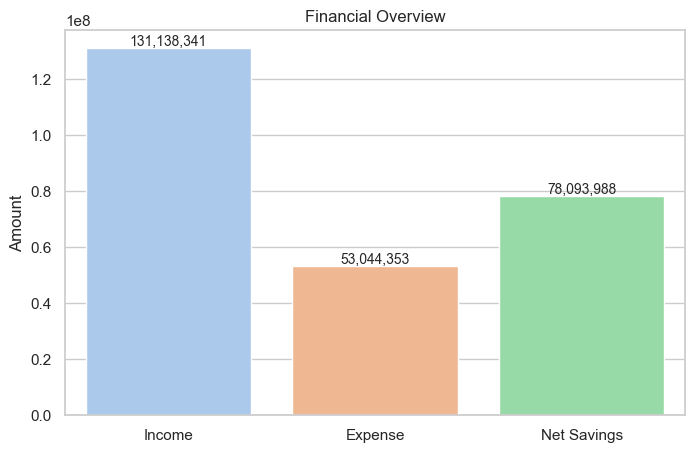

In [109]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=summary,
    x="Metric",
    y="Amount",
    palette="pastel"
)

plt.title("Financial Overview")
plt.xlabel("")
plt.ylabel("Amount")

for i, value in enumerate(summary["Amount"]):
    ax.text(i, value, f"{value:,.0f}",
            ha="center",
            va="bottom",
            fontsize=10)

plt.show()

### Findings

- The dataset contains both income and expense transactions.
- Total income, total expenses, and net savings were calculated to provide a high-level financial summary.
- Net savings indicate the overall financial position after accounting for all recorded expenses.

## 6.2 Income vs Expense Analysis

Comparing income and expenses helps evaluate the overall financial balance and understand whether income is sufficient to cover spending.

In [110]:
transaction_summary = (
    df.groupby("transaction_type")["amount"]
      .sum()
      .reset_index()
)

transaction_summary

,transaction_type,amount
0,Expense,53044353
1,Income,131138341


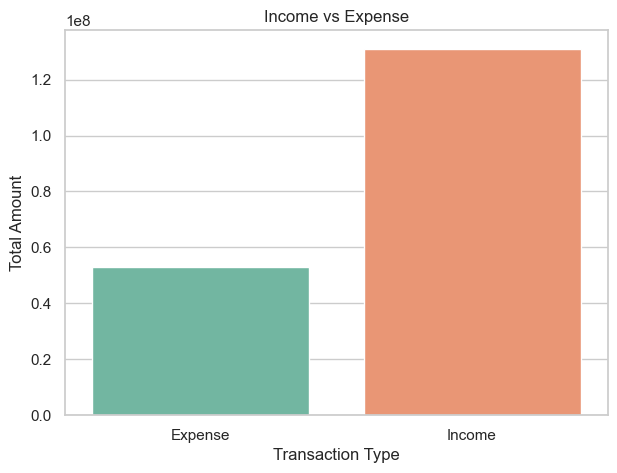

In [111]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=transaction_summary,
    x="transaction_type",
    y="amount",
    hue="transaction_type",
    palette="Set2",
    legend=False
)

plt.title("Income vs Expense")
plt.xlabel("Transaction Type")
plt.ylabel("Total Amount")

plt.show()

### Findings

- Compared the total income and total expenses.
- This comparison provides a clear understanding of the overall financial balance.
- A higher income than expenses indicates positive savings, while higher expenses may indicate overspending.

## 6.3 Expense Category Analysis

Understanding how expenses are distributed across different categories helps identify major spending areas and provides insights into spending habits.

In [112]:
expense_df = df[df["transaction_type"] == "Expense"]

In [113]:
category_expense = (
    expense_df.groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_expense

,category,amount
0,Food,16098550
1,Rent,10402111
2,Utilities,9000581
3,Travel,8206085
4,Entertainment,3890493
5,Education,2262147
6,Others,1483892
7,Savings,1421878
8,Health,163698
9,Unknown,114918


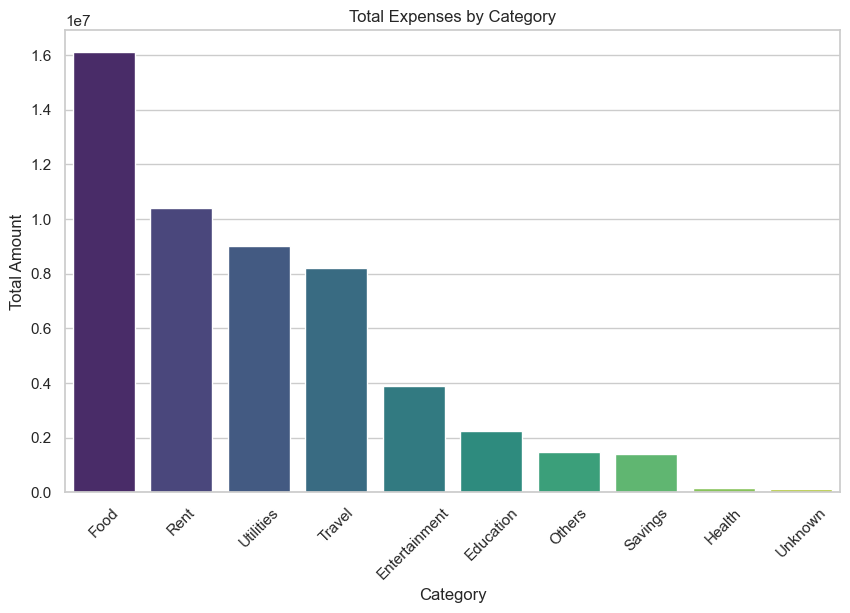

In [114]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=category_expense,
    x="category",
    y="amount",
    hue="category",
    palette="viridis",
    legend=False
)

plt.title("Total Expenses by Category")
plt.xlabel("Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)

plt.show()

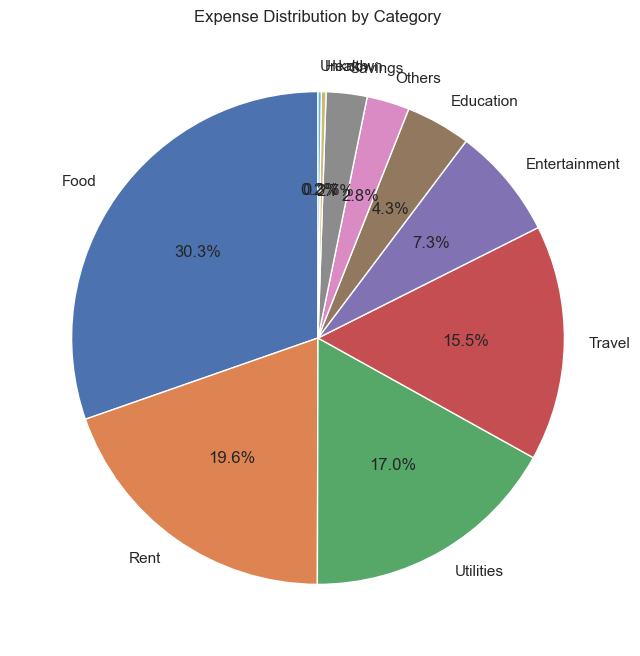

In [115]:
plt.figure(figsize=(8,8))

plt.pie(
    category_expense["amount"],
    labels=category_expense["category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Expense Distribution by Category")

plt.show()

### Findings

- Calculated the total spending for each expense category.
- Identified the categories contributing the highest and lowest expenses.
- The bar chart highlights the magnitude of spending, while the pie chart shows each category's percentage contribution to the overall expenses.

In [116]:
category_expense.head()

,category,amount
0,Food,16098550
1,Rent,10402111
2,Utilities,9000581
3,Travel,8206085
4,Entertainment,3890493


In [117]:
category_expense.tail()

,category,amount
5,Education,2262147
6,Others,1483892
7,Savings,1421878
8,Health,163698
9,Unknown,114918


## 6.4 Monthly Income and Expense Trends

Analyzing monthly income and expenses helps identify spending patterns over time, seasonal variations, and changes in financial behavior.

In [118]:
df["month"] = df["date"].dt.month_name()

In [119]:
monthly_summary = (
    df.groupby(["month", "transaction_type"])["amount"]
      .sum()
      .reset_index()
)

monthly_summary

,month,transaction_type,amount
0,April,Expense,5822640
1,April,Income,11372992
2,August,Expense,4794596
3,August,Income,11716626
4,December,Expense,7792882
5,December,Income,10742540
6,February,Expense,5831049
7,February,Income,8859666
8,January,Expense,955256
9,January,Income,11677614


In [120]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_summary["month"] = pd.Categorical(
    monthly_summary["month"],
    categories=month_order,
    ordered=True
)

monthly_summary = monthly_summary.sort_values("month")

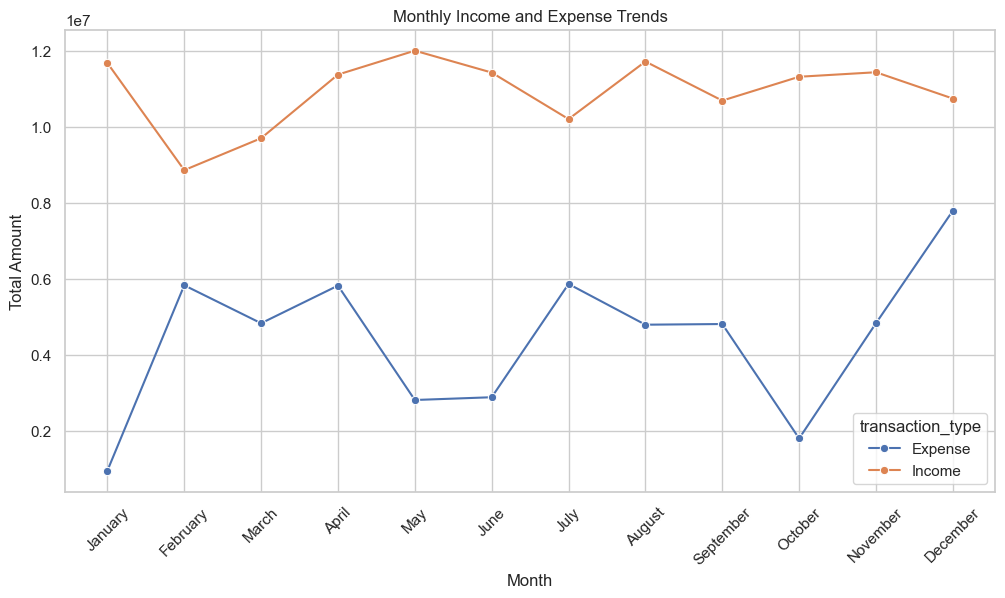

In [121]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_summary,
    x="month",
    y="amount",
    hue="transaction_type",
    marker="o"
)

plt.title("Monthly Income and Expense Trends")
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)

plt.show()

### Findings

- Monthly income and expenses were aggregated to identify financial trends over time.
- The line chart highlights fluctuations in monthly income and expenditure.
- Comparing the two trends helps identify periods of higher savings or increased spending.

## 6.5 Payment Mode Analysis

Analyzing payment methods helps understand customer payment preferences and the adoption of different transaction modes such as Cash, Card, UPI, and Bank Transfer.

In [122]:
payment_summary = (
    df["payment_mode"]
    .value_counts()
    .reset_index()
)

payment_summary.columns = ["Payment Mode", "Count"]

payment_summary

,Payment Mode,Count
0,Bank Transfer,3579
1,Cash,3533
2,Upi,3483
3,Card,3473
4,Unknown,470


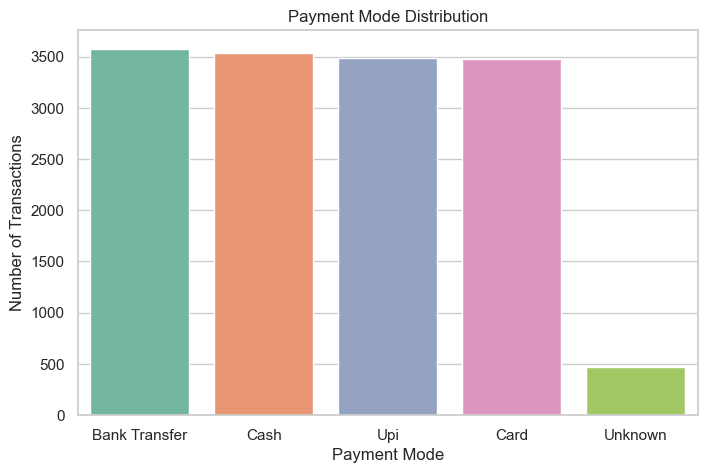

In [123]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=payment_summary,
    x="Payment Mode",
    y="Count",
    hue="Payment Mode",
    palette="Set2",
    legend=False
)

plt.title("Payment Mode Distribution")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Transactions")

plt.show()

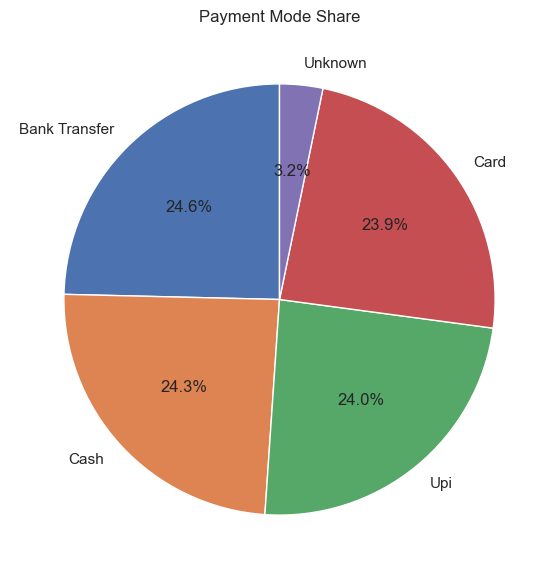

In [124]:
plt.figure(figsize=(7,7))

plt.pie(
    payment_summary["Count"],
    labels=payment_summary["Payment Mode"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Mode Share")

plt.show()

### Findings

- Calculated the frequency of each payment method.
- Compared the usage of Cash, Card, UPI, Bank Transfer, and Unknown payment modes.
- The analysis highlights the most preferred payment method and the overall distribution of transaction modes.

In [125]:
payment_summary.iloc[0]

Payment Mode    Bank Transfer
Count                    3579
Name: 0, dtype: object

## 6.6 Location-wise Analysis

Analyzing transaction locations helps identify areas with the highest transaction activity and spending. This provides insights into the geographical distribution of financial transactions.

In [126]:
location_count = (
    df["location"]
    .value_counts()
    .reset_index()
)

location_count.columns = ["Location", "Transactions"]

location_count.head(10)

,Location,Transactions
0,Hyderabad,1449
1,Pune,1425
2,Bengaluru,1418
3,Mumbai,1397
4,Jaipur,1394
5,Chennai,1386
6,Kolkata,1380
7,Delhi,1376
8,Ahmedabad,1342
9,Lucknow,1302


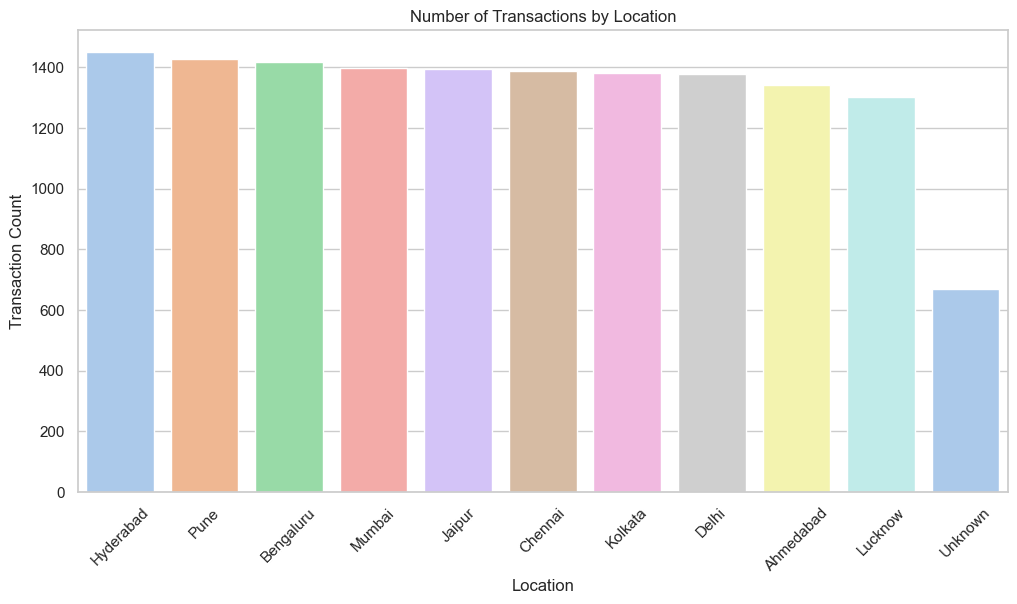

In [127]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=location_count,
    x="Location",
    y="Transactions",
    hue="Location",
    palette="pastel",
    legend=False
)

plt.title("Number of Transactions by Location")
plt.xlabel("Location")
plt.ylabel("Transaction Count")

plt.xticks(rotation=45)

plt.show()

In [128]:
location_spending = (
    expense_df.groupby("location")["amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

location_spending

,location,amount
0,Pune,7984668
1,Chennai,7027858
2,Ahmedabad,5972893
3,Hyderabad,5963669
4,Delhi,5027032
5,Kolkata,4942515
6,Jaipur,4904420
7,Unknown,4437853
8,Bengaluru,2907966
9,Lucknow,1946744


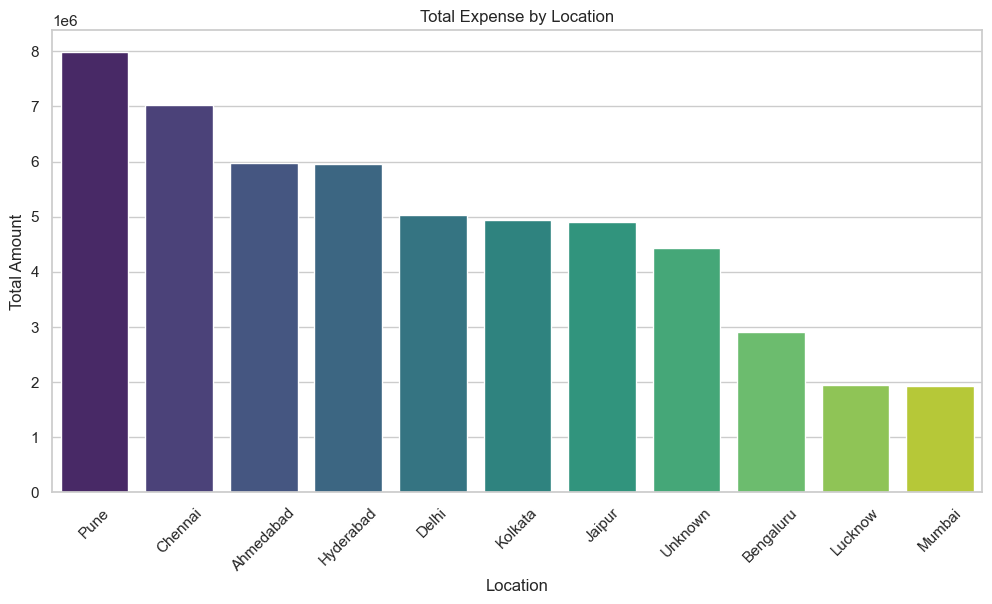

In [129]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=location_spending,
    x="location",
    y="amount",
    hue="location",
    palette="viridis",
    legend=False
)

plt.title("Total Expense by Location")
plt.xlabel("Location")
plt.ylabel("Total Amount")

plt.xticks(rotation=45)

plt.show()

### Findings

- Calculated the number of transactions across different locations.
- Compared the total expenses incurred in each location.
- Identified locations with the highest transaction activity and highest spending.
- This analysis provides insights into the geographical distribution of financial transactions.

In [130]:
location_spending.head()

,location,amount
0,Pune,7984668
1,Chennai,7027858
2,Ahmedabad,5972893
3,Hyderabad,5963669
4,Delhi,5027032


In [131]:
location_count.head()

,Location,Transactions
0,Hyderabad,1449
1,Pune,1425
2,Bengaluru,1418
3,Mumbai,1397
4,Jaipur,1394


## 6.7 Transaction Amount Distribution

Understanding the distribution of transaction amounts helps identify common spending patterns, the spread of transaction values, and the presence of unusually large or small transactions.

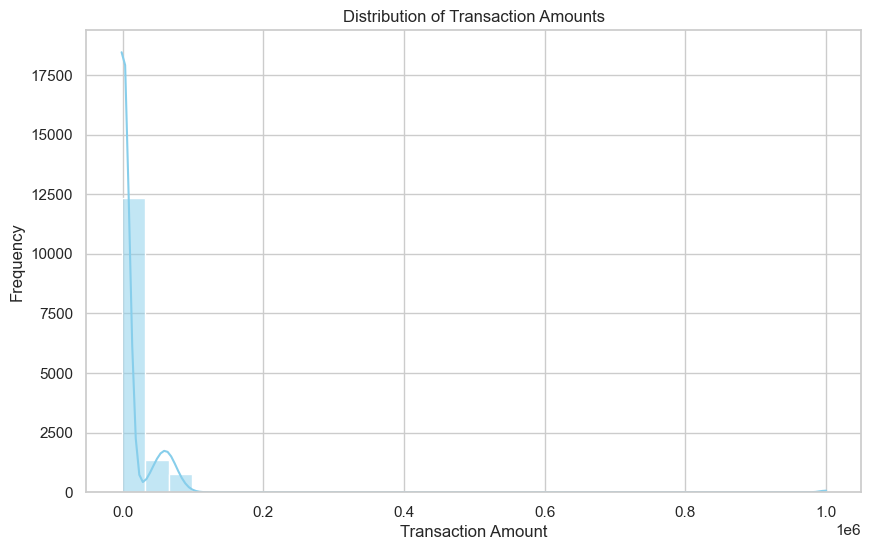

In [132]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="amount",
    bins=30,
    kde=True,
    color="skyblue"
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

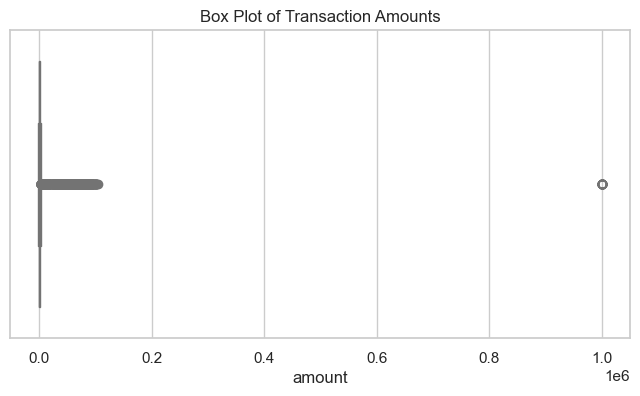

In [133]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["amount"],
    color="lightgreen"
)

plt.title("Box Plot of Transaction Amounts")

plt.show()

In [134]:
df["amount"].describe()

count     14538.000000
mean      12669.053102
std       58055.297056
min       -1313.000000
25%         203.000000
50%         533.000000
75%        1734.750000
max      999999.000000
Name: amount, dtype: float64

### Findings

- Analyzed the distribution of transaction amounts using a histogram and box plot.
- The histogram illustrates the frequency distribution of transaction values, while the KDE curve highlights the overall distribution pattern.
- The box plot helps identify potential outliers and provides a summary of the spread and central tendency of transaction amounts.

## 6.8 Correlation Analysis

Correlation analysis is typically used to measure the relationship between numerical variables.

Since this dataset contains only one primary numerical feature (`amount`), a meaningful correlation matrix cannot be generated. Therefore, correlation analysis is not applicable for this dataset.

In [135]:
df.select_dtypes(include="number").columns

Index(['amount'], dtype='str')

### Findings

- The dataset contains only one primary numerical feature (`amount`).
- Since correlation requires multiple numerical variables, a meaningful correlation analysis cannot be performed.
- Therefore, this step was omitted to avoid presenting misleading or uninformative results.

# Key Business Insights

- Total income exceeds total expenses, indicating an overall positive financial position.
- Food and Rent are the largest expense categories, suggesting that essential living costs account for a significant share of spending.
- Cash, Card, UPI, and Bank Transfer are all widely used, with no single payment method dominating the transactions.
- Monthly transaction trends show fluctuations in spending and income, highlighting periods of increased financial activity.
- Most transaction amounts fall within lower value ranges, while a small number of high-value transactions contribute to the right-skewed distribution.
- Financial activity is distributed across multiple locations, with some cities contributing a larger share of transactions and spending.

# Conclusion

This project involved cleaning, transforming, and analyzing a personal finance transaction dataset to uncover meaningful financial insights.

The data cleaning process addressed duplicate records, missing values, incorrect data types, inconsistent text formatting, and spelling variations using a combination of preprocessing techniques, RapidFuzz-based fuzzy matching, and manual validation.

Exploratory Data Analysis highlighted spending behavior, income trends, payment preferences, location-wise activity, and transaction amount distributions. These insights can support better financial planning and budgeting decisions.

Overall, the cleaned dataset provides a reliable foundation for further financial analysis, dashboard development, or predictive modeling.